# Plot

In [8]:
%pip install matplotlib seaborn

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.0-cp314-cp314-macosx_10_15_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df = pd.read_parquet("saved_data/chunks_30000_proba_v2.parquet")

In [87]:
df.head()

,title,index_of_subtext,text,mini_lm_embeddings,is_cooking_proba_logreg,is_cooking_proba_svm,is_cooking_proba_xgb
0,bostoncookingsch19hill_8_djvu,1.0,y. \n\n7 \n\n1 \n\nl \n\nj va. \n\n-.v \n\nvk ...,"[-0.010768839, -0.008792968, -0.06904796, -0.0...",0.937986,0.940503,0.999015
1,bostoncookingsch19hill_8_djvu,2.0,armer. with \nsixty illustrations in half-tone...,"[-0.06373962, -0.030786287, 0.027421873, 0.040...",0.993928,0.999999,0.999985
2,bostoncookingsch19hill_8_djvu,3.0,288 \n\nasparagus cream glace (111.) .... 429 ...,"[-0.06086176, -0.024271395, -0.021357203, -0.0...",0.976917,0.993162,0.999437
3,bostoncookingsch19hill_8_djvu,4.0,"ve always cause to dread; \nits worse in may, ...","[-0.013762968, 0.09091495, 0.12386147, -0.0075...",0.785085,0.820366,0.984210
4,bostoncookingsch19hill_8_djvu,5.0,rough the covering. she was \ndressed all in p...,"[-0.07085405, 0.04253982, 0.05266788, -0.03240...",0.788539,0.849834,0.927119


In [88]:
df = df.drop_duplicates(subset=["title", "index_of_subtext"])
df = df.head(1000)
pivot = df.pivot(
    index="title",
    columns="index_of_subtext",
    values="is_cooking_proba_logreg"
)

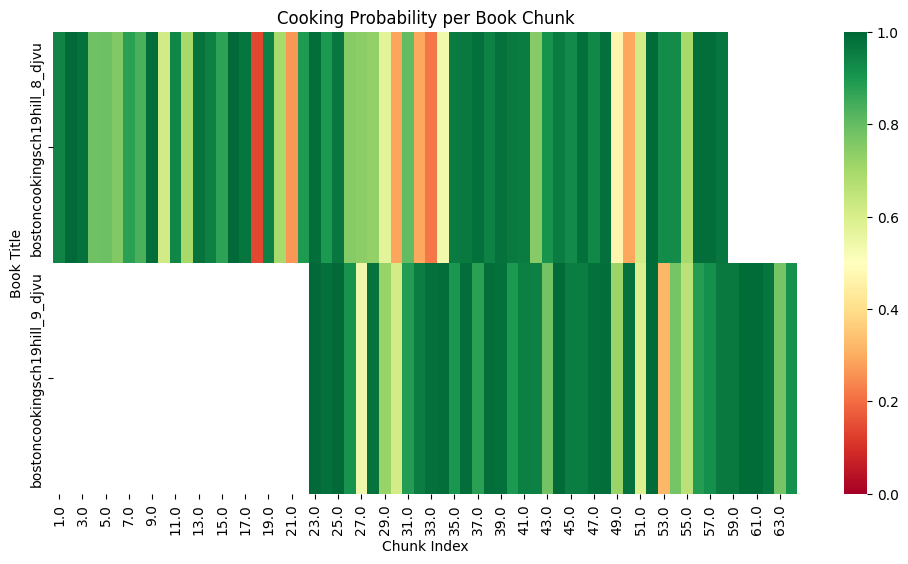

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="RdYlGn", vmin=0, vmax=1)

plt.xlabel("Chunk Index")
plt.ylabel("Book Title")
plt.title("Cooking Probability per Book Chunk")

plt.show()

In [58]:
threshold_val = 0.95
df_filtered = df[df["is_cooking_proba_logreg"] > threshold_val]

In [59]:
df_filtered.head()

,title,index_of_subtext,text,mini_lm_embeddings,is_cooking_proba_logreg,is_cooking_proba_svm,is_cooking_proba_xgb
1,bostoncookingsch19hill_8_djvu,2,armer. with \nsixty illustrations in half-tone...,"[-0.06373962, -0.030786287, 0.027421873, 0.040...",0.993928,0.999999,0.999985
2,bostoncookingsch19hill_8_djvu,3,288 \n\nasparagus cream glace (111.) .... 429 ...,"[-0.06086176, -0.024271395, -0.021357203, -0.0...",0.976917,0.993162,0.999437
8,bostoncookingsch19hill_8_djvu,9,"deep, \nbut after all, why not, and nan jumped...","[-0.028146489, -0.018194025, 0.07920719, 0.020...",0.984631,0.995652,0.999910
12,bostoncookingsch19hill_8_djvu,13,ir until \nboiling; add two cups of crab flake...,"[-0.0019822784, 0.029729795, -0.055620715, -0....",0.975498,0.990815,0.999836
15,bostoncookingsch19hill_8_djvu,16,t jelly \n\nwith hot rice pudding \n\nraisins ...,"[-0.034742422, -0.012430644, 0.047430787, 0.05...",0.992425,0.999994,0.999973


In [60]:
filtered_pivot = df_filtered.pivot(
    index="title",
    columns="index_of_subtext",
    values="is_cooking_proba_logreg"
)

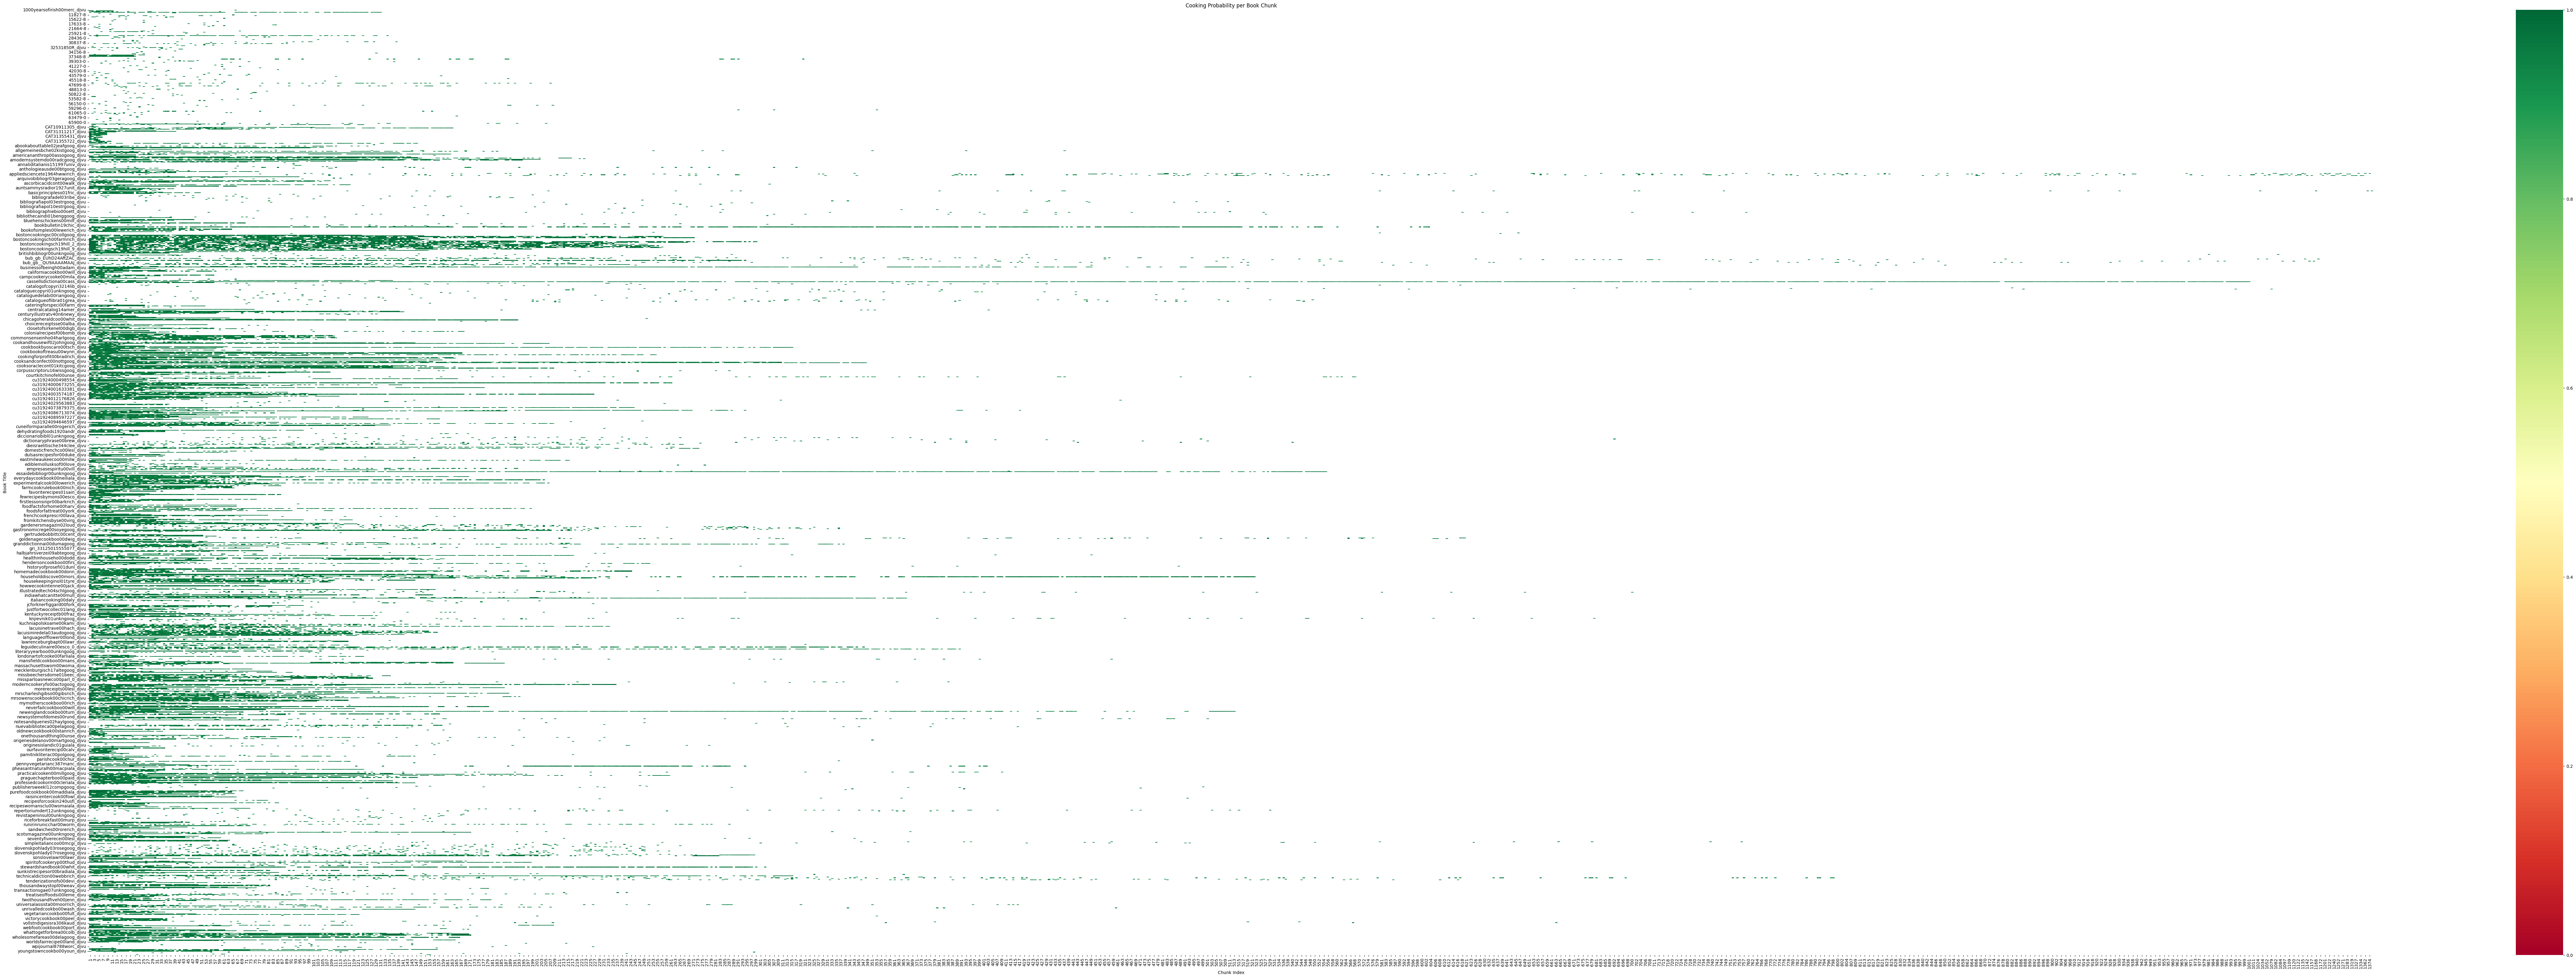

In [54]:
plt.figure(figsize=(120, 40))
sns.heatmap(filtered_pivot, cmap="RdYlGn", vmin=0, vmax=1)

plt.xlabel("Chunk Index")
plt.ylabel("Book Title")
plt.title("Cooking Probability per Book Chunk")

plt.show()

In [67]:
df_filtered.iloc[1300]['text']

'ons, a little parsley, summer savory and pepper, either \nblack or cayenne. then a layer of split boston, or butter, or whole cream \ncrackers, which have been soaked in warm water until moistened through, \nbut not ready to break. above this put a layer of pork and repeat the \norder given above  onions, seasoning (not too much), crackers and pork, \nuntil your materials are exhausted. let the topmost layer be buttered \ncrackers well soaked. pour in enough cold water to barely cover all. \ncover the pot, stew gently for an hour, watching that the water does not \nsink too low. should it leave the upper layer exposed, replenish cau- \ntiously from the boiling tea-kettle. when the chowder is thoroughly \ndone, take out with a perforated skimmer and put into a tureen. thicken \nthe gravy with a tablespoonful of flour and about the same quantity of \nbutter; boil up and pour over the chowder. serve sliced lemon, pickles \nand stewed tomatoes with it, that the guests may add if they like

In [68]:
df_filtered.describe()

,index_of_subtext,is_cooking_proba_logreg,is_cooking_proba_svm,is_cooking_proba_xgb
count,34008.000000,34008.000000,34008.000000,34008.000000
mean,85.828540,0.972774,0.988042,0.995553
std,111.287565,0.012234,0.012608,0.018292
min,1.000000,0.950000,0.846543,0.398896
25%,20.000000,0.962785,0.983708,0.997696
50%,52.000000,0.973018,0.991625,0.999374
75%,110.000000,0.982663,0.996150,0.999798
max,1368.000000,0.999313,1.000000,0.999995


In [69]:
df_filtered.to_parquet("saved_data/chunks_7500_95logreg.parquet", index=False)